# Oppgave 1 — Implementasjon og sammenligning av PLSR-algoritmer
**MLA310 — Project 1**

Implementerer og sammenligner tre PLS-algoritmer:
- `pls_nip`: NIPALS (med normalisering av scores og weights)
- `bidiag2`: Golub-Kahan Lanczos bidiagonalisering med reortogonalisering
- `plshy`: Hybrid PLS (Bidiag2 + y-deflasjon)

In [2]:
using LinearAlgebra, Statistics, MAT, BenchmarkTools, Plots

## 1a) Implementasjon av algoritmene
### PLS_nip — NIPALS med normalisering

In [3]:
function pls_nip(X, y; mc=2)
    m, n = size(X)
    mc = min(mc, min(n, m) - 1)
    T = zeros(m, mc); W = zeros(n, mc); P = zeros(n, mc)
    q = zeros(mc)
    x̄ = mean(X, dims=1)
    ȳ = mean(y)
    y = copy(y) .- ȳ
    X = copy(X) .- x̄

    for a in 1:mc
        w = X' * y;  w = w / norm(w);  W[:, a] = w
        t = X * w;   t = t / norm(t);  T[:, a] = t
        P[:, a] = X' * t
        X = X - t * P[:, a]'
        q[a] = dot(y, t)
        y = y - q[a] * t
    end

    # Regresjonskoeffisienter
    R = W / triu(P' * W)          
    β  = cumsum(R .* q', dims=2)  
    β₀ = fill(ȳ, 1, mc) .- x̄ * β 
    return β₀, β, T, W, P, q
end

pls_nip (generic function with 1 method)

### Bidiag2 — laster inn fra fil

In [4]:
include("bidiag2.jl")

bidiag2 (generic function with 1 method)

### PLSHY — Hybrid bidiagonalisering med y-deflasjon


In [7]:
function plshy(X, y; mc=2)
    m, n = size(X)
    mc = min(mc, min(n, m) - 1)
    T = zeros(m, mc); W = zeros(n, mc)
    β = zeros(n, mc)
    q = zeros(mc)
    x̄ = mean(X, dims=1)
    ȳ = mean(y)
    y = copy(y) .- ȳ
    X = copy(X) .- x̄
    B = zeros(mc, 2) 

    w0 = X' * y;  w = w0 / norm(w0)
    t  = X * w;   ρ = norm(t);  t = t / ρ
    q[1] = dot(y, t)
    W[:, 1] = w;  T[:, 1] = t;  B[1, 1] = ρ
    d = w / ρ
    β[:, 1] = q[1] * d
    y = y - t * q[1]  

    for a in 2:mc
        w1 = X' * y
        w  = (w0 - w1) / q[a-1] - ρ * w   
        w0 = w1
        w = w - W[:, 1:a-1] * (W[:, 1:a-1]' * w)
        θ = norm(w);  w = w / θ
        t = X * w
        t = t - T[:, 1:a-1] * (T[:, 1:a-1]' * t)
        ρ = norm(t);  t = t / ρ
        q[a] = dot(y, t)
        W[:, a] = w;  T[:, a] = t
        B[a-1, 2] = θ;  B[a, 1] = ρ
        d = (w - θ * d) / ρ
        β[:, a] = β[:, a-1] + q[a] * d
        y = y - t * q[a]  
    end

    B_bidiag = Bidiagonal(B[:, 1], B[1:mc-1, 2], :U)
    β₀ = fill(ȳ, 1, mc) .- x̄ * β
    return β₀, β, T, B_bidiag, W, q
end

plshy (generic function with 1 method)

## 1b) Verifisering på spectra.mat (NIR/Oktan)
X: 60 prøver × 401 NIR-bølgelengder, y: oktantall

In [8]:
vars = matread("spectra.mat")
X = Float64.(vars["NIR"])
y = vec(Float64.(vars["octane"]))
m, n = size(X)
println("Datasett: m=$m prøver, n=$n bølgelengder")

Datasett: m=60 prøver, n=401 bølgelengder


In [9]:
mc = 10

β₀_nip, β_nip, T_nip, W_nip, P_nip, q_nip = pls_nip(X, y; mc=mc)
β₀_b2,  β_b2,  T_b2,  B_b2,  W_b2,  q_b2  = bidiag2(X, y; mc=mc)
β₀_hy,  β_hy,  T_hy,  B_hy,  W_hy,  q_hy  = plshy(X, y; mc=mc)

for k in [1, 5, 10]
    d_nip_b2 = norm(β_nip[:,k] - β_b2[:,k]) / norm(β_b2[:,k])
    d_nip_hy = norm(β_nip[:,k] - β_hy[:,k]) / norm(β_hy[:,k])
    d_b2_hy  = norm(β_b2[:,k]  - β_hy[:,k]) / norm(β_hy[:,k])
    println("k=$k: NIP vs B2=$(round(d_nip_b2, sigdigits=3)),  NIP vs HY=$(round(d_nip_hy, sigdigits=3)),  B2 vs HY=$(round(d_b2_hy, sigdigits=3))")
end

for k in [1, 5, 10]
    d = norm(β₀_nip[:,k] - β₀_b2[:,k])
    println("k=$k: |β₀_nip - β₀_b2| = $(round(d, sigdigits=3))")
end

for k in 1:min(3, mc)
    d = norm(abs.(T_nip[:,k]) - abs.(T_b2[:,k])) / norm(T_b2[:,k])
    println("Komponent $k: NIP vs B2 = $(round(d, sigdigits=3))")
end

for k in 1:min(3, mc)
    d = norm(abs.(W_nip[:,k]) - abs.(W_b2[:,k])) / norm(W_b2[:,k])
    println("Komponent $k: NIP vs B2 = $(round(d, sigdigits=3))")
end

k=1: NIP vs B2=4.43e-17,  NIP vs HY=4.43e-17,  B2 vs HY=0.0
k=5: NIP vs B2=4.82e-15,  NIP vs HY=3.88e-15,  B2 vs HY=5.82e-15
k=10: NIP vs B2=5.49e-14,  NIP vs HY=3.95e-14,  B2 vs HY=6.49e-14
k=1: |β₀_nip - β₀_b2| = 0.0
k=5: |β₀_nip - β₀_b2| = 4.26e-14
k=10: |β₀_nip - β₀_b2| = 3.55e-13
Komponent 1: NIP vs B2 = 0.0
Komponent 2: NIP vs B2 = 3.94e-16
Komponent 3: NIP vs B2 = 2.54e-16
Komponent 1: NIP vs B2 = 0.0
Komponent 2: NIP vs B2 = 4.56e-16
Komponent 3: NIP vs B2 = 1.52e-15


### Plot av regresjonskoeffisienter for utvalgte komponenter

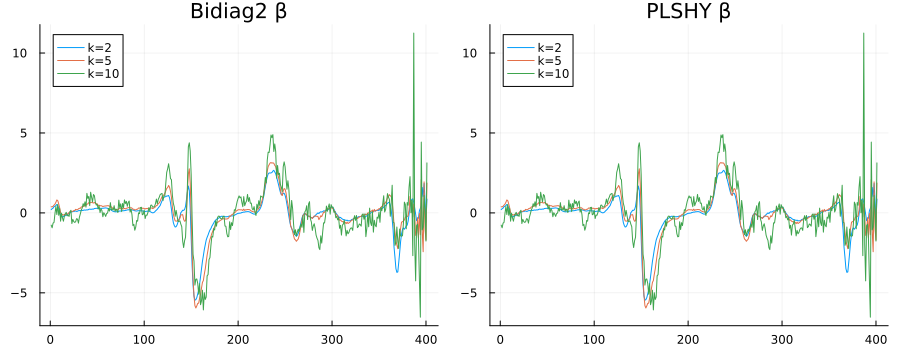

In [10]:
p = plot(layout=(1,2), size=(900,350))
for k in [2, 5, 10]
    plot!(p[1], β_b2[:,k], label="k=$k", title="Bidiag2 β")
    plot!(p[2], β_hy[:,k], label="k=$k", title="PLSHY β")
end
display(p)

## 1c) Sammenligning av beregningstid med LooCV
Tilfeldig datasett: X (300×1000), y (300×1), opp til 10 PLS-komponenter.

In [14]:
using Random
Random.seed!(42)
m_r, n_r, mc_r = 300, 1000, 10
Xr = randn(m_r, n_r)
yr = randn(m_r)

300-element Vector{Float64}:
 -0.7428593790518899
  0.9338657291255386
 -0.4621076048609636
  0.7763001733130079
 -0.01450178247330087
 -0.1005627327071922
 -0.29328264687396327
 -0.33129096818150316
  0.2337168990275653
 -1.7758708526541045
  ⋮
 -0.5577178500488501
  0.9080688361950524
 -0.5001594029662842
 -0.3366933524254914
 -2.349015541548413
  0.22499619095976753
  0.3397761661012281
 -0.5673482569047802
  0.1645463179879431

In [11]:
# Generell LooCV-funksjon for PLS-algoritmer
function pls_loocv(X, y, mc_max, plsfun)
    m = size(X, 1)
    ypred = zeros(m, mc_max)
    for i in 1:m
        idx = [1:i-1; i+1:m]
        β₀_i, β_i = plsfun(X[idx, :], y[idx]; mc=mc_max)
        for k in 1:mc_max
            ypred[i, k] = (X[i:i, :] * β_i[:, k] .+ β₀_i[:, k])[1]
        end
    end
    rmsecv = sqrt.(mean((y .- ypred).^2, dims=1)[:])
    return rmsecv
end

pls_loocv (generic function with 1 method)

In [15]:

t_nip = @elapsed rmsecv_nip = pls_loocv(Xr, yr, mc_r, pls_nip)
println("  pls_nip  : $(round(t_nip, digits=3)) s")

t_b2  = @elapsed rmsecv_b2  = pls_loocv(Xr, yr, mc_r, bidiag2)
println("  bidiag2  : $(round(t_b2, digits=3)) s")

t_hy  = @elapsed rmsecv_hy  = pls_loocv(Xr, yr, mc_r, plshy)
println("  plshy    : $(round(t_hy, digits=3)) s")

  pls_nip  : 9.429 s
  bidiag2  : 1.006 s
  plshy    : 1.19 s


In [ ]:
bar(["pls_nip", "bidiag2", "plshy"], [t_nip, t_b2, t_hy],
    ylabel="Tid (s)", title="LooCV beregningstid (m=$m_r, n=$n_r, mc=$mc_r)",
    legend=false, color=[:steelblue, :orange, :green])

In [ ]:
plot(1:mc_r, rmsecv_nip, label="pls_nip", marker=:circle,
     xlabel="Antall PLS-komponenter", ylabel="RMSECV",
     title="LooCV prediksjonsfeil — tilfeldig datasett")
plot!(1:mc_r, rmsecv_b2, label="bidiag2", marker=:square)
plot!(1:mc_r, rmsecv_hy, label="plshy", marker=:diamond)